# Hands-on Bayesian Neural Networks — Paper Summary + Visualization Notebook

This notebook is a study companion for:

**Laurent Valentin Jospin, Hamid Laga, Farid Boussaid, Wray Buntine, Mohammed Bennamoun, “Hands-on Bayesian Neural Networks — A Tutorial for Deep Learning Users.”**

The goal is not only to summarize the paper, but also to make the core ideas visible through small executable examples.

You will see:

1. The difference between **frequentist** and **Bayesian** interpretations of probability.
2. How Fig. 1 maps ordinary deep-learning concepts to Bayesian neural-network concepts.
3. How **prior + likelihood** produce a **posterior**.
4. How a point-estimate neural network differs from a Bayesian neural network.
5. How **Bayes-by-Backprop** approximates a posterior over weights.
6. How **MC-Dropout** gives approximate Bayesian uncertainty.
7. How to visualize predictive uncertainty and calibration.

> Runtime note: the examples are intentionally small and CPU-friendly. They are designed for learning, not state-of-the-art accuracy.

## 0. Optional installation

Run this cell only if your environment is missing packages.

```python
%pip install torch matplotlib numpy scikit-learn
```

In [14]:
import math
import random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Keep tiny neural-network examples fast on CPU.
try:
    torch.set_num_threads(1)
except Exception:
    pass

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('torch:', torch.__version__)
print('numpy:', np.__version__)

torch: 2.11.0+cpu
numpy: 2.4.4


# 1. Main message of the paper

The paper explains Bayesian Neural Networks (BNNs) for people who already know ordinary deep learning.

A standard neural network usually learns one best parameter vector:

$$
\hat{\theta} = \arg\min_\theta \mathcal{L}(\theta).
$$

A Bayesian neural network instead treats the parameters as uncertain and learns a posterior distribution:

$$
p(\theta \mid D)
= \frac{p(D \mid \theta)p(\theta)}{p(D)}.
$$

The final prediction is not made by one network only. It averages over many plausible networks:

$$
p(y^* \mid x^*, D)
= \int p(y^* \mid x^*, \theta)p(\theta \mid D)d\theta.
$$

In practice, this integral is approximated by sampling:

$$
\theta_1,\dots,\theta_T \sim p(\theta \mid D),
$$

then averaging predictions:

$$
\hat{p}(y^* \mid x^*, D)
\approx
\frac{1}{T}\sum_{t=1}^T p(y^* \mid x^*, \theta_t).
$$

The key benefit is **uncertainty quantification**. A BNN can express: “I am not sure,” especially when the input is far from the training distribution.

# 2. Fig. 1 explained: ordinary deep learning vs Bayesian deep learning

Fig. 1 of the paper is a conceptual map. It says that many things you already know in deep learning have Bayesian counterparts.

| Ordinary deep learning concept | Bayesian neural-network concept | Meaning |
|---|---|---|
| Architecture | Functional model | The deterministic function form, e.g., MLP, CNN, ResNet. |
| Loss function | Stochastic model | The probabilistic assumptions behind data and parameters. |
| Cross-entropy / MSE | Negative log-likelihood | The data-fitting term. |
| Regularization | Prior | A belief about parameters before seeing data. |
| Training | Inference | Estimating a posterior distribution, not just one optimum. |
| Backpropagation | Bayes-by-Backprop | Backpropagation-compatible variational inference. |
| Dropout | MC-Dropout | Dropout kept active at test time to sample predictions. |
| One best model | Posterior over many models | A distribution over plausible weights. |

A compact way to remember Fig. 1 is:

$$
\text{posterior} \propto \text{likelihood} \times \text{prior}.
$$

In loss form:

$$
-\log p(\theta \mid D)
= -\log p(D \mid \theta) - \log p(\theta) + \text{constant}.
$$

So a regularized deep-learning loss can often be interpreted as a Bayesian objective.

# 3. Visualization: prior + likelihood = posterior

Before going into neural networks, let us visualize Bayes' theorem in a one-parameter toy problem.

Assume there is an unknown scalar parameter $\theta$. We observe noisy measurements:

$$
y_i = \theta + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, \sigma_y^2).
$$

We place a Gaussian prior on $\theta$:

$$
\theta \sim \mathcal{N}(\mu_0, \sigma_0^2).
$$

Because Gaussian prior and Gaussian likelihood are conjugate, the posterior is also Gaussian:

$$
p(\theta \mid D) = \mathcal{N}(\mu_N, \sigma_N^2).
$$

This example shows the second key Bayesian idea from the paper:

> prior beliefs influence posterior beliefs.

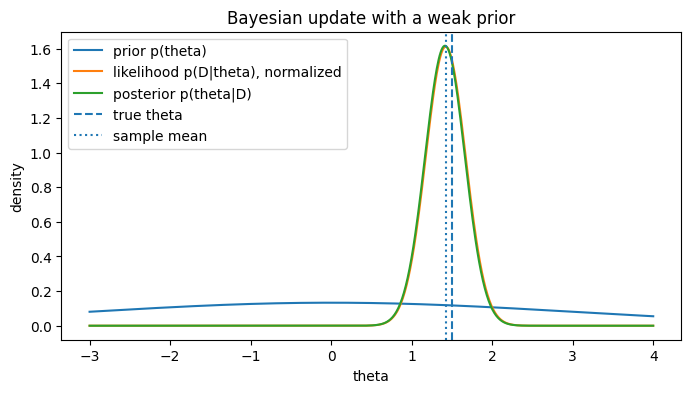

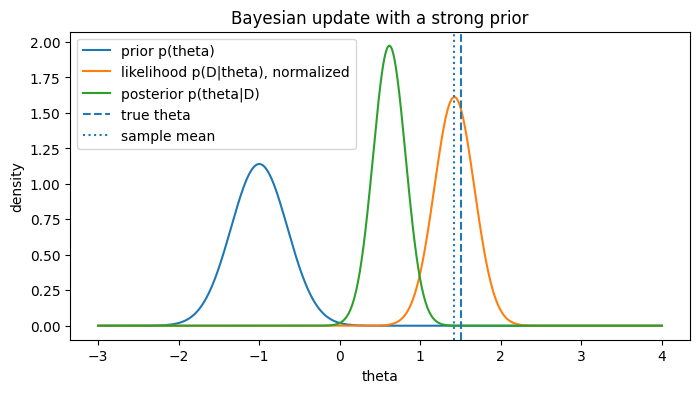

observations: [2.683 1.174 1.523 1.785 0.948 1.501 1.499 0.272]
sample mean: 1.423


In [15]:
def normal_pdf(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

# Synthetic observations from an unknown scalar theta.
true_theta = 1.5
sigma_y = 0.7
n_obs = 8
observations = true_theta + sigma_y * np.random.randn(n_obs)
y_bar = observations.mean()

theta_grid = np.linspace(-3, 4, 600)

def gaussian_posterior_params(mu0, sigma0, y, sigma_y):
    n = len(y)
    precision_prior = 1 / sigma0**2
    precision_likelihood = n / sigma_y**2
    sigmaN2 = 1 / (precision_prior + precision_likelihood)
    muN = sigmaN2 * (mu0 / sigma0**2 + y.sum() / sigma_y**2)
    return muN, math.sqrt(sigmaN2)

prior_settings = [
    {'name': 'weak prior', 'mu0': 0.0, 'sigma0': 3.0},
    {'name': 'strong prior', 'mu0': -1.0, 'sigma0': 0.35},
]

for setting in prior_settings:
    mu0, sigma0 = setting['mu0'], setting['sigma0']
    muN, sigmaN = gaussian_posterior_params(mu0, sigma0, observations, sigma_y)

    prior_pdf = normal_pdf(theta_grid, mu0, sigma0)
    # Likelihood as a function of theta, normalized for plotting.
    likelihood = np.prod(normal_pdf(observations[:, None], theta_grid[None, :], sigma_y), axis=0)
    likelihood = likelihood / np.trapezoid(likelihood, theta_grid)
    posterior_pdf = normal_pdf(theta_grid, muN, sigmaN)

    plt.figure(figsize=(8, 4))
    plt.plot(theta_grid, prior_pdf, label='prior p(theta)')
    plt.plot(theta_grid, likelihood, label='likelihood p(D|theta), normalized')
    plt.plot(theta_grid, posterior_pdf, label='posterior p(theta|D)')
    plt.axvline(true_theta, linestyle='--', label='true theta')
    plt.axvline(y_bar, linestyle=':', label='sample mean')
    plt.title(f"Bayesian update with a {setting['name']}")
    plt.xlabel('theta')
    plt.ylabel('density')
    plt.legend()
    plt.show()

print('observations:', np.round(observations, 3))
print('sample mean:', round(float(y_bar), 3))

## Interpretation

The weak prior lets the data dominate. The strong prior pulls the posterior toward the prior mean.

This is exactly the idea used in BNNs, except that $\theta$ is no longer one scalar. It is a very high-dimensional vector containing all neural-network weights.

For a BNN:

$$
p(\theta \mid D) \propto p(D_y \mid D_x, \theta)p(\theta).
$$

- $p(D_y \mid D_x, \theta)$ is the **likelihood**.
- $p(\theta)$ is the **prior over weights**.
- $p(\theta \mid D)$ is the **posterior over weights**.

# 4. Point-estimate neural network: one best parameter value

The next example uses a noisy 1D regression problem. There is a gap in the training data around $x=0$.

A point-estimate network can fit the data, but it does not naturally say: “I am uncertain in the gap.”

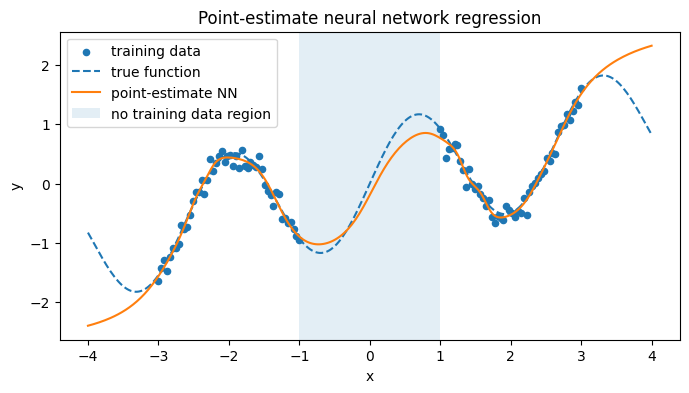

In [16]:
def make_regression_data(n_per_region=50, noise_std=0.12):
    x_left = torch.linspace(-3.0, -1.0, n_per_region).unsqueeze(1)
    x_right = torch.linspace(1.0, 3.0, n_per_region).unsqueeze(1)
    x = torch.cat([x_left, x_right], dim=0)
    y_clean = torch.sin(2.4 * x) + 0.25 * x
    y = y_clean + noise_std * torch.randn_like(y_clean)
    return x, y

x_train, y_train = make_regression_data()
x_grid = torch.linspace(-4.0, 4.0, 300).unsqueeze(1)
true_grid = torch.sin(2.4 * x_grid) + 0.25 * x_grid

class DeterministicMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x)

det_model = DeterministicMLP()
optimizer = torch.optim.Adam(det_model.parameters(), lr=0.01)

for epoch in range(900):
    optimizer.zero_grad()
    pred = det_model(x_train)
    loss = F.mse_loss(pred, y_train)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    det_pred = det_model(x_grid)

plt.figure(figsize=(8, 4))
plt.scatter(x_train.squeeze(), y_train.squeeze(), s=20, label='training data')
plt.plot(x_grid.squeeze(), true_grid.squeeze(), linestyle='--', label='true function')
plt.plot(x_grid.squeeze(), det_pred.squeeze(), label='point-estimate NN')
plt.axvspan(-1, 1, alpha=0.12, label='no training data region')
plt.title('Point-estimate neural network regression')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# 5. Bayes-by-Backprop: learning a distribution over weights

Bayes-by-Backprop is a variational inference method for BNNs.

Instead of one weight value $w$, each weight has a variational distribution:

$$
q_\phi(w) = \mathcal{N}(\mu, \sigma^2).
$$

The network samples weights using the reparameterization trick:

$$
w = \mu + \sigma \epsilon, \quad \epsilon \sim \mathcal{N}(0,1).
$$

The training objective is ELBO-like:

$$
\mathcal{L}
= \underbrace{-\log p(D \mid \theta)}_{\text{data fit / NLL}}
+ \underbrace{\mathrm{KL}(q_\phi(\theta) \Vert p(\theta))}_{\text{posterior close to prior}}.
$$

For stability in this small educational notebook, we use a beta-scaled KL term:

$$
\mathcal{L}
= \mathrm{MSE} + \beta \frac{\mathrm{KL}}{N}.
$$

This is not meant to be the only valid BNN objective. It is a lightweight way to show the mechanism.

In [17]:
class BayesianLinear(nn.Module):
    # Linear layer with a factorized Gaussian variational posterior.
    def __init__(self, in_features, out_features, prior_sigma=1.0):
        super().__init__()
        self.prior_sigma = prior_sigma
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features).normal_(0, 0.10))
        self.weight_rho = nn.Parameter(torch.full((out_features, in_features), -3.0))
        self.bias_mu = nn.Parameter(torch.zeros(out_features))
        self.bias_rho = nn.Parameter(torch.full((out_features,), -3.0))
        self._last_kl = torch.tensor(0.0)

    @staticmethod
    def rho_to_sigma(rho):
        return F.softplus(rho) + 1e-6

    def _kl_normal(self, mu, sigma):
        prior_sigma = torch.as_tensor(self.prior_sigma, device=mu.device, dtype=mu.dtype)
        return torch.log(prior_sigma / sigma) + (sigma.pow(2) + mu.pow(2)) / (2 * prior_sigma.pow(2)) - 0.5

    def forward(self, x, sample=True):
        weight_sigma = self.rho_to_sigma(self.weight_rho)
        bias_sigma = self.rho_to_sigma(self.bias_rho)

        if sample:
            weight = self.weight_mu + weight_sigma * torch.randn_like(weight_sigma)
            bias = self.bias_mu + bias_sigma * torch.randn_like(bias_sigma)
        else:
            weight = self.weight_mu
            bias = self.bias_mu

        self._last_kl = (
            self._kl_normal(self.weight_mu, weight_sigma).sum()
            + self._kl_normal(self.bias_mu, bias_sigma).sum()
        )
        return F.linear(x, weight, bias)

    @property
    def kl(self):
        return self._last_kl

class BayesianMLP(nn.Module):
    def __init__(self, prior_sigma=1.0):
        super().__init__()
        self.l1 = BayesianLinear(1, 64, prior_sigma)
        self.l2 = BayesianLinear(64, 64, prior_sigma)
        self.l3 = BayesianLinear(64, 1, prior_sigma)

    def forward(self, x, sample=True):
        x = torch.tanh(self.l1(x, sample=sample))
        x = torch.tanh(self.l2(x, sample=sample))
        return self.l3(x, sample=sample)

    def kl(self):
        return self.l1.kl + self.l2.kl + self.l3.kl

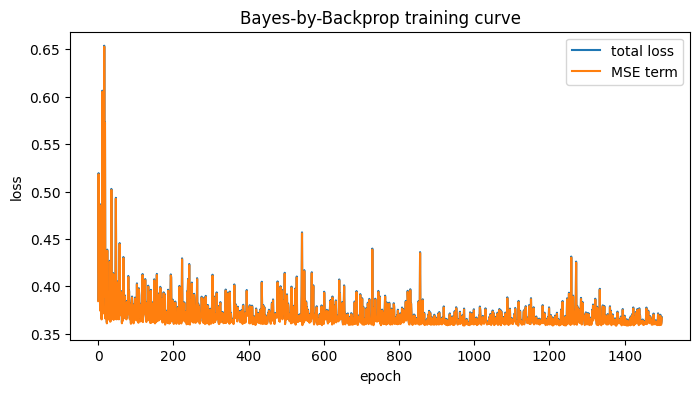

In [18]:
bnn = BayesianMLP(prior_sigma=1.0)
optimizer = torch.optim.Adam(bnn.parameters(), lr=0.01)
N = len(x_train)
beta_kl = 1e-5
history = []

for epoch in range(1500):
    optimizer.zero_grad()
    pred = bnn(x_train, sample=True)
    mse = F.mse_loss(pred, y_train, reduction='mean')
    kl = bnn.kl()
    loss = mse + beta_kl * kl / N
    loss.backward()
    optimizer.step()
    history.append((float(loss.detach()), float(mse.detach()), float((kl / N).detach())))

history = np.array(history)

plt.figure(figsize=(8, 4))
plt.plot(history[:, 0], label='total loss')
plt.plot(history[:, 1], label='MSE term')
plt.title('Bayes-by-Backprop training curve')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

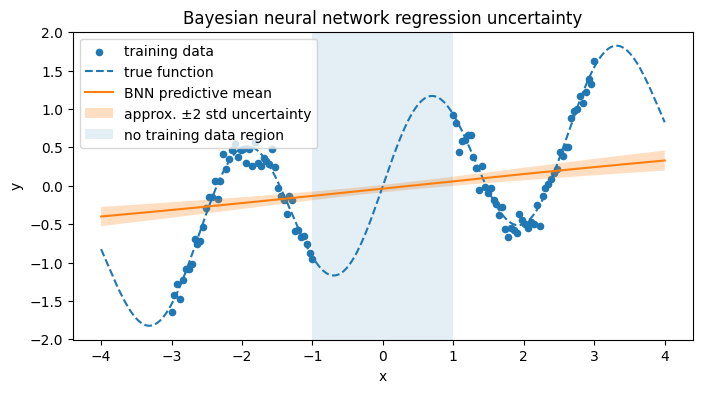

In [19]:
def predict_bnn(model, x, n_samples=200):
    model.eval()
    preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            preds.append(model(x, sample=True).squeeze(-1))
    preds = torch.stack(preds, dim=0)
    return preds.mean(dim=0), preds.std(dim=0), preds

bnn_mean, bnn_std, bnn_samples = predict_bnn(bnn, x_grid, n_samples=200)

plt.figure(figsize=(8, 4))
plt.scatter(x_train.squeeze(), y_train.squeeze(), s=20, label='training data')
plt.plot(x_grid.squeeze(), true_grid.squeeze(), linestyle='--', label='true function')
plt.plot(x_grid.squeeze(), bnn_mean, label='BNN predictive mean')
plt.fill_between(
    x_grid.squeeze().numpy(),
    (bnn_mean - 2 * bnn_std).numpy(),
    (bnn_mean + 2 * bnn_std).numpy(),
    alpha=0.25,
    label='approx. ±2 std uncertainty',
)
plt.axvspan(-1, 1, alpha=0.12, label='no training data region')
plt.title('Bayesian neural network regression uncertainty')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## What to notice

A BNN prediction is a distribution, not a single curve.

For each input $x$, the model samples many plausible networks:

$$
\theta_t \sim q_\phi(\theta), \quad y_t = f_{\theta_t}(x).
$$

Then we summarize:

$$
\text{predictive mean} = \frac{1}{T}\sum_t y_t,
$$

$$
\text{predictive uncertainty} \approx \mathrm{std}(y_1,\dots,y_T).
$$

This is the practical meaning of the posterior predictive distribution in the paper.

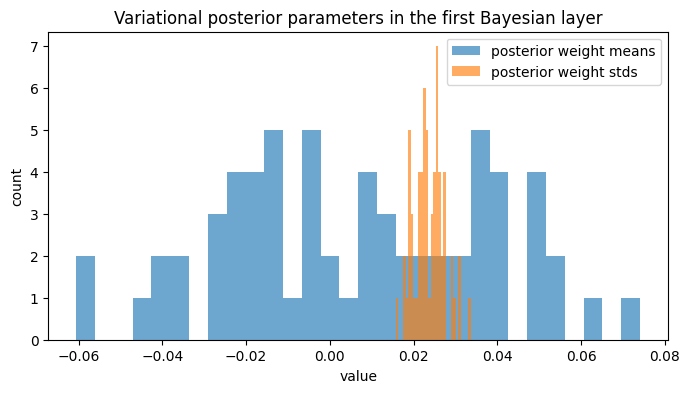

In [20]:
# Inspect the learned variational posterior of the first Bayesian layer.
layer = bnn.l1
weight_mu = layer.weight_mu.detach().flatten().numpy()
weight_sigma = layer.rho_to_sigma(layer.weight_rho).detach().flatten().numpy()

plt.figure(figsize=(8, 4))
plt.hist(weight_mu, bins=30, alpha=0.65, label='posterior weight means')
plt.hist(weight_sigma, bins=30, alpha=0.65, label='posterior weight stds')
plt.title('Variational posterior parameters in the first Bayesian layer')
plt.xlabel('value')
plt.ylabel('count')
plt.legend()
plt.show()

# 6. MCMC vs Variational Inference: why approximate inference is hard

The paper explains that exact Bayesian inference is hard for neural networks because the posterior can be high-dimensional, non-convex, and multimodal.

This toy example uses a simple one-dimensional multimodal target posterior:

$$
p(\theta) = 0.5\,\mathcal{N}(-2, 0.35^2) + 0.5\,\mathcal{N}(2, 0.35^2).
$$

We compare:

- **MCMC**: draws samples from the target distribution.
- **Mean-field VI**: fits one Gaussian. It may collapse to one mode.
- **Ensemble-style approximation**: uses multiple components to cover multiple modes.

This mirrors the paper's discussion: MCMC is more faithful but expensive; VI is scalable but approximate; ensembles can help cover multiple modes.

MCMC acceptance rate: 0.419
VI Gaussian: mu = 1.989 sigma = 0.346


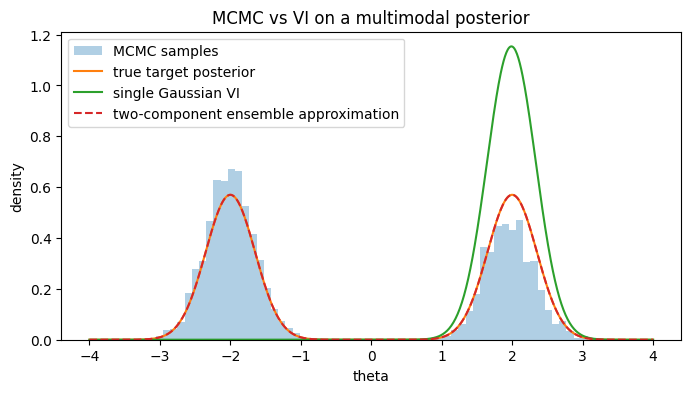

In [21]:
def log_mixture_target(theta):
    normal1 = torch.distributions.Normal(torch.tensor(-2.0), torch.tensor(0.35))
    normal2 = torch.distributions.Normal(torch.tensor(2.0), torch.tensor(0.35))
    logp1 = math.log(0.5) + normal1.log_prob(theta)
    logp2 = math.log(0.5) + normal2.log_prob(theta)
    return torch.logsumexp(torch.stack([logp1, logp2]), dim=0)

def metropolis_1d(log_prob, start=0.0, n_steps=12000, burn_in=1000, proposal_std=0.9):
    current = torch.tensor(float(start))
    current_logp = log_prob(current)
    samples = []
    accepted = 0
    for i in range(n_steps):
        proposal = current + proposal_std * torch.randn(())
        proposal_logp = log_prob(proposal)
        if torch.log(torch.rand(())) < proposal_logp - current_logp:
            current = proposal
            current_logp = proposal_logp
            accepted += 1
        if i >= burn_in and i % 3 == 0:
            samples.append(float(current))
    return np.array(samples), accepted / n_steps

mcmc_samples, accept_rate = metropolis_1d(log_mixture_target)
print('MCMC acceptance rate:', round(accept_rate, 3))

# Fit q(theta)=Normal(mu, sigma) by minimizing KL(q||p), estimated with reparameterization.
mu = torch.nn.Parameter(torch.tensor(1.0))
rho = torch.nn.Parameter(torch.tensor(-0.5))
opt = torch.optim.Adam([mu, rho], lr=0.03)

for step in range(1200):
    opt.zero_grad()
    sigma = F.softplus(rho) + 1e-6
    eps = torch.randn(512)
    theta = mu + sigma * eps
    q = torch.distributions.Normal(mu, sigma)
    loss = (q.log_prob(theta) - log_mixture_target(theta)).mean()
    loss.backward()
    opt.step()

vi_mu = float(mu.detach())
vi_sigma = float((F.softplus(rho) + 1e-6).detach())
print('VI Gaussian: mu =', round(vi_mu, 3), 'sigma =', round(vi_sigma, 3))

xx = np.linspace(-4, 4, 800)
target_pdf = 0.5 * normal_pdf(xx, -2, 0.35) + 0.5 * normal_pdf(xx, 2, 0.35)
vi_pdf = normal_pdf(xx, vi_mu, vi_sigma)
ensemble_pdf = 0.5 * normal_pdf(xx, -2, 0.35) + 0.5 * normal_pdf(xx, 2, 0.35)

plt.figure(figsize=(8, 4))
plt.hist(mcmc_samples, bins=60, density=True, alpha=0.35, label='MCMC samples')
plt.plot(xx, target_pdf, label='true target posterior')
plt.plot(xx, vi_pdf, label='single Gaussian VI')
plt.plot(xx, ensemble_pdf, linestyle='--', label='two-component ensemble approximation')
plt.title('MCMC vs VI on a multimodal posterior')
plt.xlabel('theta')
plt.ylabel('density')
plt.legend()
plt.show()

# 7. MC-Dropout: a practical approximate Bayesian method

Dropout is usually introduced as a regularization method.

The Bayesian interpretation used in the paper is:

1. Train a network with dropout.
2. At test time, keep dropout active.
3. Run many stochastic forward passes.
4. Average predictions and measure disagreement.

For classification:

$$
\hat{p}(y \mid x, D) \approx \frac{1}{T}\sum_{t=1}^T \mathrm{softmax}(f_t(x)).
$$

The predictive entropy is:

$$
H[y \mid x, D] = -\sum_c \hat{p}_c \log \hat{p}_c.
$$

High entropy means the model is uncertain.

In [22]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=800, noise=0.25, random_state=SEED)
X = StandardScaler().fit_transform(X).astype('float32')
y = y.astype('int64')

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

X_train_cls = torch.tensor(X_train_np)
y_train_cls = torch.tensor(y_train_np)
X_test_cls = torch.tensor(X_test_np)
y_test_cls = torch.tensor(y_test_np)

class DropoutMLP(nn.Module):
    def __init__(self, p_drop=0.20):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(64, 2),
        )
    def forward(self, x):
        return self.net(x)

mc_model = DropoutMLP(p_drop=0.20)
optimizer = torch.optim.Adam(mc_model.parameters(), lr=0.01)

for epoch in range(450):
    mc_model.train()
    optimizer.zero_grad()
    logits = mc_model(X_train_cls)
    loss = F.cross_entropy(logits, y_train_cls)
    loss.backward()
    optimizer.step()

mc_model.eval()
with torch.no_grad():
    test_logits = mc_model(X_test_cls)
    point_acc = (test_logits.argmax(dim=1) == y_test_cls).float().mean().item()
print('Point-estimate dropout model test accuracy:', round(point_acc, 3))

Point-estimate dropout model test accuracy: 0.929


In [23]:
def mc_dropout_predict(model, x, n_samples=100):
    # Important: train() keeps dropout active.
    model.train()
    probs = []
    with torch.no_grad():
        for _ in range(n_samples):
            logits = model(x)
            probs.append(F.softmax(logits, dim=1))
    probs = torch.stack(probs, dim=0)
    mean_probs = probs.mean(dim=0)
    entropy = -(mean_probs * torch.log(mean_probs + 1e-8)).sum(dim=1)
    return mean_probs, entropy, probs

mean_probs_test, entropy_test, probs_samples_test = mc_dropout_predict(mc_model, X_test_cls, n_samples=100)
confidence_test, pred_test = mean_probs_test.max(dim=1)
mc_acc = (pred_test == y_test_cls).float().mean().item()
print('MC-Dropout test accuracy:', round(mc_acc, 3))
print('Average predictive entropy:', round(float(entropy_test.mean()), 3))

MC-Dropout test accuracy: 0.933
Average predictive entropy: 0.153


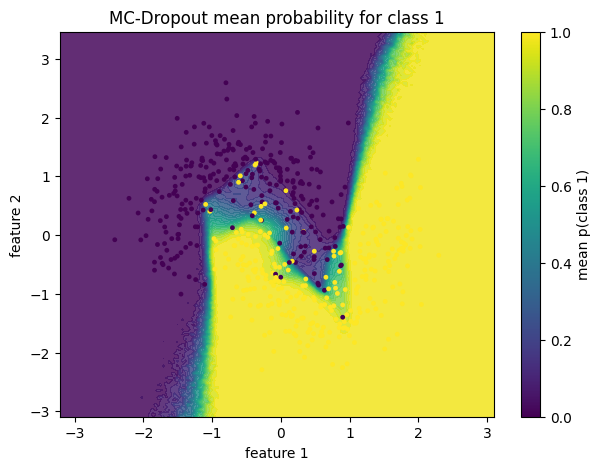

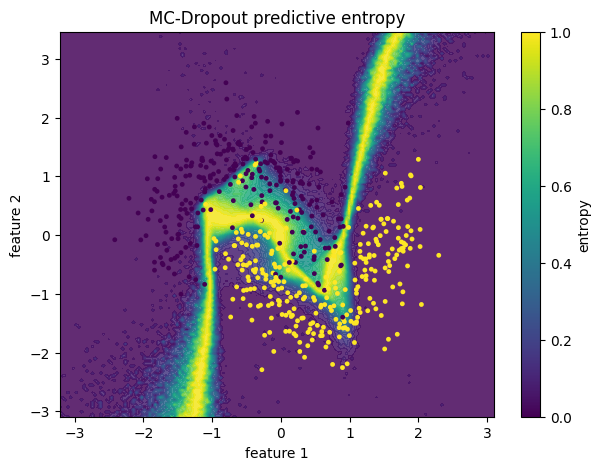

In [24]:
# Visualize predictive probability and uncertainty over the 2D input space.
x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 160), np.linspace(y_min, y_max, 160))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()].astype('float32'))

mean_probs_grid, entropy_grid, _ = mc_dropout_predict(mc_model, grid, n_samples=80)
prob_class1 = mean_probs_grid[:, 1].reshape(xx.shape).numpy()
entropy_map = entropy_grid.reshape(xx.shape).numpy()

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, prob_class1, levels=30, alpha=0.85)
plt.scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, s=12, edgecolors='none')
plt.title('MC-Dropout mean probability for class 1')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.colorbar(label='mean p(class 1)')
plt.show()

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, entropy_map, levels=30, alpha=0.85)
plt.scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, s=12, edgecolors='none')
plt.title('MC-Dropout predictive entropy')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.colorbar(label='entropy')
plt.show()

# 8. Calibration curve / reliability diagram

The paper emphasizes that BNNs should be evaluated not only by accuracy, but also by **calibration**.

A model is well calibrated if, among all predictions made with confidence 0.8, about 80% are correct.

For classification, a reliability diagram compares:

$$
\text{average confidence in bin}
\quad \text{vs.} \quad
\text{empirical accuracy in bin}.
$$

Expected calibration error (ECE) is a common summary:

$$
\mathrm{ECE} = \sum_{b=1}^{B} \frac{|B_b|}{N}
\left|\mathrm{acc}(B_b)-\mathrm{conf}(B_b)\right|.
$$

ECE: 0.0183


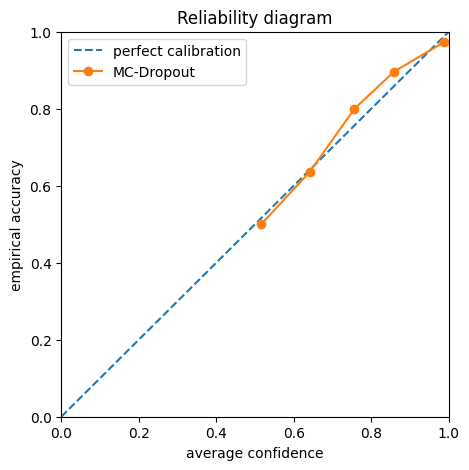

In [25]:
def calibration_statistics(confidence, predictions, labels, n_bins=10):
    confidence = confidence.detach().cpu()
    predictions = predictions.detach().cpu()
    labels = labels.detach().cpu()

    bins = torch.linspace(0.0, 1.0, n_bins + 1)
    bin_centers = []
    bin_confidences = []
    bin_accuracies = []
    bin_counts = []
    ece = 0.0

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidence > lo) & (confidence <= hi)
        count = int(mask.sum())
        if count > 0:
            acc = (predictions[mask] == labels[mask]).float().mean().item()
            conf = confidence[mask].mean().item()
            frac = count / len(labels)
            ece += frac * abs(acc - conf)
            bin_centers.append(float((lo + hi) / 2))
            bin_confidences.append(conf)
            bin_accuracies.append(acc)
            bin_counts.append(count)

    return {
        'bin_centers': np.array(bin_centers),
        'bin_confidences': np.array(bin_confidences),
        'bin_accuracies': np.array(bin_accuracies),
        'bin_counts': np.array(bin_counts),
        'ece': ece,
    }

cal = calibration_statistics(confidence_test, pred_test, y_test_cls, n_bins=10)
print('ECE:', round(cal['ece'], 4))

plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], linestyle='--', label='perfect calibration')
plt.plot(cal['bin_confidences'], cal['bin_accuracies'], marker='o', label='MC-Dropout')
plt.title('Reliability diagram')
plt.xlabel('average confidence')
plt.ylabel('empirical accuracy')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

# 9. Method comparison summary

| Method | Core idea | Strength | Weakness | When to use |
|---|---|---|---|---|
| MCMC | Sample from the posterior using a Markov chain | More faithful Bayesian sampling | Expensive for large neural networks | Small models, posterior diagnostics, gold-standard checks |
| Variational inference | Approximate posterior with a simpler distribution $q_\phi(\theta)$ | Scalable and compatible with deep learning | Can underestimate uncertainty or collapse to one mode | Practical BNN training |
| Bayes-by-Backprop | VI for neural nets using reparameterized weights | Easy to implement with PyTorch | Sensitive to KL scaling and variational family | Educational and practical BNNs |
| MC-Dropout | Keep dropout active at test time | Very easy to retrofit | Limited posterior expressiveness | Quick uncertainty estimates |
| Deep ensembles | Train multiple networks from different initializations | Strong empirical uncertainty baseline | Requires storing several models | Robust practical uncertainty estimation |

The paper's practical message is not that one method is always best. Rather:

> BNNs provide a Bayesian language for uncertainty, but real deep-learning models usually require approximate inference.

# 10. Final cheat sheet

## Bayesian learning

$$
p(\theta \mid D) \propto p(D \mid \theta)p(\theta)
$$

## BNN posterior predictive

$$
p(y^* \mid x^*, D) = \int p(y^* \mid x^*, \theta)p(\theta \mid D)d\theta
$$

## Monte Carlo approximation

$$
\hat{p}(y^* \mid x^*, D)
\approx
\frac{1}{T}\sum_{t=1}^T p(y^* \mid x^*, \theta_t)
$$

## Regularization as prior

$$
\lambda ||\theta||_2^2
\quad \Longleftrightarrow \quad
\theta \sim \mathcal{N}(0, \sigma^2 I)
$$

## BNN uncertainty intuition

If sampled networks agree:

$$
\text{low uncertainty}
$$

If sampled networks disagree:

$$
\text{high uncertainty}
$$

## The one-sentence summary

A Bayesian neural network replaces “learn one best neural network” with “learn a distribution over plausible neural networks, then use their agreement or disagreement to quantify uncertainty.”

# 11. Suggested exercises

1. Change the prior standard deviation in `BayesianMLP(prior_sigma=...)` and observe how the uncertainty changes.
2. Increase or decrease `beta_kl` and observe the fit/uncertainty tradeoff.
3. Change the dropout rate in `DropoutMLP(p_drop=...)` and check the entropy map.
4. Compare MC-Dropout calibration against a deterministic network without dropout.
5. Replace the toy regression data with your own dataset.

These experiments directly connect to the paper's discussion of priors, likelihoods, approximate inference, and calibration.

# References

- Jospin, L. V., Laga, H., Boussaid, F., Buntine, W., & Bennamoun, M. **Hands-on Bayesian Neural Networks — A Tutorial for Deep Learning Users.** arXiv:2007.06823.
- Blundell, C., Cornebise, J., Kavukcuoglu, K., & Wierstra, D. **Weight Uncertainty in Neural Networks.** ICML 2015.
- Gal, Y., & Ghahramani, Z. **Dropout as a Bayesian Approximation: Representing Model Uncertainty in Deep Learning.** ICML 2016.
- Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. **On Calibration of Modern Neural Networks.** ICML 2017.